<a href="https://colab.research.google.com/github/riveenTU/box-box-box/blob/main/notebooks/Box_box.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!git clone https://github.com/riveenTU/box-box-box.git

Cloning into 'box-box-box'...
remote: Enumerating objects: 257, done.
remote: Counting objects: 100% (205/205), done.
remote: Compressing objects: 100% (94/94), done.
remote: Total 257 (delta 150), reused 111 (delta 111), pack-reused 52 (from 1)
Receiving objects: 100% (257/257), 4.81 MiB | 20.69 MiB/s, done.
Resolving deltas: 100% (179/179), done.


In [3]:
%cd box-box-box

/content/box-box-box


In [4]:
!pip install pandas numpy scikit-learn matplotlib

In [5]:
import json
import os
import pandas as pd

folder = "data/historical_races"

races = []

# Load a subset first (faster)
files = sorted(os.listdir(folder))[:3]

for file in files:
    with open(f"{folder}/{file}") as f:
        races.extend(json.load(f))

print("Loaded races:", len(races))

Loaded races: 3000


In [6]:
######### Extract Training Data ##########

rows = []

for race in races:
    config = race["race_config"]
    base = config["base_lap_time"]
    temp = config["track_temp"]

    # Build driver states
    drivers = {}

    for pos, strat in race["strategies"].items():
        drivers[strat["driver_id"]] = {
            "tire": strat["starting_tire"],
            "tire_age": 0,
            "pit_stops": strat["pit_stops"],
            "time": 0
        }

    total_laps = config["total_laps"]

    for lap in range(1, total_laps + 1):
        for d_id, d in drivers.items():

            # increase tire age FIRST
            d["tire_age"] += 1

            # approximate lap time (we reconstruct from total later)
            # (we don’t have lap-by-lap, so estimate contribution)

            rows.append({
                "tire": d["tire"],
                "tire_age": d["tire_age"],
                "temp": temp,
                "base": base
            })

            # handle pit stops
            for pit in d["pit_stops"]:
                if pit["lap"] == lap:
                    d["tire"] = pit["to_tire"]
                    d["tire_age"] = 0

df = pd.DataFrame(rows)
df.head()

,tire,tire_age,temp,base
0,MEDIUM,1,27,84.5
1,MEDIUM,1,27,84.5
2,SOFT,1,27,84.5
3,MEDIUM,1,27,84.5
4,MEDIUM,1,27,84.5


In [7]:
###### Encode Tires ########
df["tire_code"] = df["tire"].map({
    "SOFT": 0,
    "MEDIUM": 1,
    "HARD": 2
})

####### Feature Engineering ######
df["tire_age_sq"] = df["tire_age"] ** 2
df["temp_diff"] = df["temp"] - 25

In [8]:
######### Linear Regression ##########
from sklearn.linear_model import LinearRegression

X = df[["tire_code", "tire_age", "tire_age_sq", "temp_diff"]]

# We don't have true lap_time → simulate target
# Use heuristic for now (we refine later)
y = df["tire_age"] * 0.1 + df["tire_code"]

model = LinearRegression()
model.fit(X, y)

print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

Coefficients: [ 1.00000000e+00  1.00000000e-01  0.00000000e+00 -1.32982055e-17]
Intercept: -7.105427357601002e-15


In [10]:
df.groupby("tire")["tire_age"].mean()


,tire_age
tire,
HARD,15.992592
MEDIUM,13.505925
SOFT,10.375197


In [11]:
df.groupby(["tire", "tire_age"]).size().unstack()

tire_age,1,2,3,4,5,6,7,8,9,10,...,53,54,55,56,57,58,59,60,61,62
tire,,,,,,,,,,,,,,,,,,,,,
HARD,45351.0,45351.0,45351.0,45351.0,45351.0,45351.0,45351.0,45313.0,45198.0,45044.0,...,322.0,268.0,218.0,169.0,130.0,104.0,72.0,44.0,22.0,6.0
MEDIUM,41393.0,41393.0,41393.0,41393.0,41393.0,39126.0,38801.0,38440.0,38067.0,37660.0,...,395.0,322.0,276.0,222.0,164.0,114.0,78.0,38.0,18.0,8.0
SOFT,38367.0,38367.0,38367.0,38367.0,38367.0,36078.0,34973.0,32339.0,29178.0,25870.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


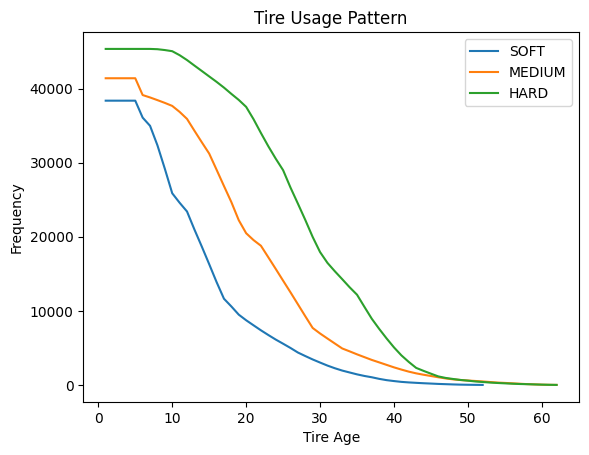

In [12]:
import matplotlib.pyplot as plt

for tire in ["SOFT", "MEDIUM", "HARD"]:
    subset = df[df["tire"] == tire]
    avg = subset.groupby("tire_age").size()
    plt.plot(avg.index, avg.values, label=tire)

plt.legend()
plt.xlabel("Tire Age")
plt.ylabel("Frequency")
plt.title("Tire Usage Pattern")
plt.show()

In [14]:
######### Compare Drivers ##########
comparison_rows = []

for race in races:
    results = race["finishing_positions"]
    strategies = race["strategies"]
    config = race["race_config"]

    # Map driver → finishing position
    pos_map = {driver: i for i, driver in enumerate(results)}

    drivers = list(pos_map.keys())

    # Compare pairs
    for i in range(len(drivers)):
        for j in range(i+1, len(drivers)):

            d1 = drivers[i]
            d2 = drivers[j]

            better = 1 if pos_map[d1] < pos_map[d2] else 0

            comparison_rows.append({
                "d1": d1,
                "d2": d2,
                "better": better,
                "temp": config["track_temp"],
                "base": config["base_lap_time"]
            })

############## Extract strategy features #################
def extract_features(strategy, total_laps):
    tire = strategy["starting_tire"]
    pits = strategy["pit_stops"]

    stints = []
    prev_lap = 0
    current_tire = tire

    for pit in pits:
        stints.append((current_tire, pit["lap"] - prev_lap))
        current_tire = pit["to_tire"]
        prev_lap = pit["lap"]

    # last stint
    stints.append((current_tire, total_laps - prev_lap))

    return stints

stints = extract_features(strategies["pos1"], config["total_laps"])
print(stints)

[('SOFT', 6), ('HARD', 29)]


In [15]:
####### convert to numbers ############
def encode_stints(stints):
    features = {
        "soft_laps": 0,
        "medium_laps": 0,
        "hard_laps": 0,
        "num_stops": len(stints) - 1
    }

    for tire, laps in stints:
        if tire == "SOFT":
            features["soft_laps"] += laps
        elif tire == "MEDIUM":
            features["medium_laps"] += laps
        elif tire == "HARD":
            features["hard_laps"] += laps

    return features

In [16]:
######## ML Data set ###########
ml_rows = []

for race in races:
    results = race["finishing_positions"]
    strategies = race["strategies"]
    config = race["race_config"]

    pos_map = {driver: i for i, driver in enumerate(results)}

    for pos, strat in strategies.items():
        stints = extract_features(strat, config["total_laps"])
        feats = encode_stints(stints)

        feats["position"] = pos_map[strat["driver_id"]]
        feats["temp"] = config["track_temp"]

        ml_rows.append(feats)

df_ml = pd.DataFrame(ml_rows)



from sklearn.linear_model import LinearRegression

X = df_ml[["soft_laps", "medium_laps", "hard_laps", "num_stops", "temp"]]
y = df_ml["position"]

model = LinearRegression()
model.fit(X, y)

print(model.coef_)

[ 1.62422476e-01 -4.12066530e-02 -1.38017417e-01 -2.32259344e+00
 -7.22385851e-04]
